In [ ]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [2]:
data_annotated_path = "/home/bmb/haxx/working/ceisel_mumm/data/"
data = sc.read_h5ad(data_annotated_path + "full_annotations_leiden.h5ad")

data.shape

/home/bmb/miniconda3/envs/ceisel_mumm/lib/python3.14/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


(126807, 5057)

In [3]:
data.obs

,annotated,Unnamed: 0,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,Cell.ID,Condition,batch,...,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,library,n_counts,log_total_counts,exp_condition,time,leiden,cell_type
AAACCCAAGCATGGGT-1,True,24_48_AAACCCAAGCATGGGT-1,RGC_scRNA,1260,786,2.936508,0.077778,24_48_AAACCCAAGCATGGGT-1,24h_Cntr,NaN,...,40.396825,53.492063,77.301587,1,1260.0,7.139660,Cntr,24,10,Horizontal cells
AAACCCAAGGTACAAT-1,True,24_48_AAACCCAAGGTACAAT-1,RGC_scRNA,744,469,2.956989,0.086022,24_48_AAACCCAAGGTACAAT-1,24h_Cntr,NaN,...,50.403226,63.844086,100.000000,1,744.0,6.613384,Cntr,24,1,Bipolar cells
AAACCCACACTCTCGT-1,True,24_48_AAACCCACACTCTCGT-1,RGC_scRNA,1031,635,0.969932,0.066925,24_48_AAACCCACACTCTCGT-1,24h_Cntr,NaN,...,42.870999,57.807953,86.905917,1,1031.0,6.939254,Cntr,24,15,Bipolar cells
AAACCCAGTCAGCTTA-1,True,24_48_AAACCCAGTCAGCTTA-1,RGC_scRNA,4932,1463,6.285483,0.045215,24_48_AAACCCAGTCAGCTTA-1,24h_Cntr,NaN,...,52.980535,62.875101,78.913220,1,4932.0,8.503702,Cntr,24,12,Cones
AAACCCAGTCGCTTAA-1,True,24_48_AAACCCAGTCGCTTAA-1,RGC_scRNA,1030,459,3.300971,0.083495,24_48_AAACCCAGTCGCTTAA-1,24h_Cntr,NaN,...,60.194175,74.854369,100.000000,1,1030.0,6.938284,Cntr,24,12,Cones
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGTCAAACCCA-4,True,12_72_TTTGTTGTCAAACCCA-4,RGC_scRNA,3056,1433,2.879581,0.078534,12_72_TTTGTTGTCAAACCCA-4,72h_Mtz,NaN,...,41.034031,51.472513,69.469895,4,3056.0,8.025189,Mtz,72,8,Horizontal cells
TTTGTTGTCCTCACGT-4,True,12_72_TTTGTTGTCCTCACGT-4,RGC_scRNA,1570,813,3.184713,0.050318,12_72_TTTGTTGTCCTCACGT-4,72h_Mtz,NaN,...,47.898089,60.636943,80.063694,4,1570.0,7.359468,Mtz,72,0,Bipolar cells
TTTGTTGTCGAGATGG-4,True,12_72_TTTGTTGTCGAGATGG-4,RGC_scRNA,1548,800,2.131783,0.038114,12_72_TTTGTTGTCGAGATGG-4,72h_Mtz,NaN,...,50.129199,61.240310,80.620155,4,1548.0,7.345365,Mtz,72,3,Bipolar cells
TTTGTTGTCGCGTGCA-4,True,12_72_TTTGTTGTCGCGTGCA-4,RGC_scRNA,5631,2357,2.273131,0.091458,12_72_TTTGTTGTCGCGTGCA-4,72h_Mtz,NaN,...,39.953852,48.597799,62.548811,4,5634.0,8.636752,Mtz,72,11,11


In [4]:
data.layers['raw'] = np.array(data.layers['raw'].astype(int).todense())

# Pseudobulking

In [5]:
import anndata as ad
pseudobulks = []

n_pseduo_bulks = 1

for cell_type in sorted(list(set(data.obs['cell_type']))):
    if cell_type == 'trash':
        continue
    for condition in set(data.obs['exp_condition']):
        for time in sorted(list(set(data.obs['time']))):
            # print(cell_type,condition,time)
            mask = (
                (data.obs['cell_type'] == cell_type) & \
                (data.obs['exp_condition'] == condition) & \
                (data.obs['time'] == time) \
            )
            mask_split = np.random.randint(n_pseduo_bulks,size=mask.shape)
            submasks = [mask & (mask_split == i) for i in range(n_pseduo_bulks)]
            for submask in submasks:
                counts = data.layers['raw'][submask].sum(axis=0)
                annd = ad.AnnData(counts.reshape(1,-1))
                annd.obs['cell_type'] = cell_type
                annd.obs['exp_condition'] = condition
                annd.obs['time'] = time

                annd.obs['cell_type'] = annd.obs['cell_type'].astype('category')
                annd.obs['exp_condition'] = annd.obs['exp_condition'].astype('category')
                annd.obs['time'] = annd.obs['time'].astype('category')
                

                pseudobulks.append(annd)
            
pseudobulks = ad.concat(pseudobulks)
pseudobulks.obs_names_make_unique()

/home/bmb/miniconda3/envs/ceisel_mumm/lib/python3.14/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
pseudobulks.obs

,cell_type,exp_condition,time
0,11,Cntr,12
0-1,11,Cntr,24
0-2,11,Cntr,48
0-3,11,Cntr,72
0-4,11,Mtz,12
...,...,...,...
0-131,Undifferentiated,Cntr,72
0-132,Undifferentiated,Mtz,12
0-133,Undifferentiated,Mtz,24
0-134,Undifferentiated,Mtz,48


In [7]:
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=pseudobulks.X+1,
    metadata=pseudobulks.obs,
    # design="~exp_condition*cell_type",
    design="~ exp_condition + cell_type + time + exp_condition:time + exp_condition:cell_type",
    refit_cooks=True,
    inference=inference,
)

In [8]:
dds.obs["cell_type"].cat.categories

Index(['5', '7', '11', '23', '26', '27', '29', 'Amacrine cells',
       'Bipolar cells', 'Cones', 'Horizontal cells', 'Microglia',
       'Muller glia', 'PR precursors', 'RGCs', 'Rods', 'Undifferentiated'],
      dtype='object')

In [9]:
# Sets RGCs as the reference population for all relative changes

excluded_categories = list(dds.obs["cell_type"].cat.categories.unique())
excluded_categories.remove("RGCs")
dds.obs["cell_type"] = dds.obs["cell_type"].cat.reorder_categories([
    "RGCs",
    *excluded_categories,
]) 

In [10]:
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.37 seconds.

Fitting dispersion trend curve...
/home/bmb/miniconda3/envs/ceisel_mumm/lib/python3.14/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.67 seconds.

Fitting LFCs...
... done in 0.63 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [11]:
ds = DeseqStats(dds, contrast=["exp_condition", "Mtz", "Cntr"], inference=inference)

In [12]:
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: exp_condition Mtz vs Cntr
       baseMean  log2FoldChange      lfcSE      stat    pvalue      padj
0      9.800912       -0.905076  16.030837 -0.056458  0.954977  0.999988
1      1.477499       19.362570  17.723965  1.092451  0.274635  0.999988
2      2.483753       -3.188192  15.610688 -0.204231  0.838173  0.999988
3     12.241269       -4.112561  12.769282 -0.322067  0.747402  0.999988
4     24.647190       12.265997  15.056502  0.814664  0.415264  0.999988
...         ...             ...        ...       ...       ...       ...
5052   3.417333      -17.984209  13.471094 -1.335022  0.181869  0.999988
5053   1.548768      -22.290791  16.397368 -1.359413  0.174016  0.999988
5054   1.190669       -6.236074  20.652066 -0.301959  0.762683  0.999988
5055   1.518864      -30.485424  18.712476 -1.629150  0.103281  0.999988
5056  61.723389       32.206641  13.797301  2.334271  0.019582  0.999988

[5057 rows x 6 columns]


... done in 0.16 seconds.



### Volcano Plot

In [13]:
ds.LFC


,Intercept,exp_condition[T.Mtz],cell_type[T.7],cell_type[T.11],cell_type[T.23],cell_type[T.26],cell_type[T.27],cell_type[T.29],cell_type[T.Amacrine cells],cell_type[T.Bipolar cells],...,exp_condition[T.Mtz]:cell_type[T.Amacrine cells],exp_condition[T.Mtz]:cell_type[T.Bipolar cells],exp_condition[T.Mtz]:cell_type[T.Cones],exp_condition[T.Mtz]:cell_type[T.Horizontal cells],exp_condition[T.Mtz]:cell_type[T.Microglia],exp_condition[T.Mtz]:cell_type[T.Muller glia],exp_condition[T.Mtz]:cell_type[T.PR precursors],exp_condition[T.Mtz]:cell_type[T.RGCs],exp_condition[T.Mtz]:cell_type[T.Rods],exp_condition[T.Mtz]:cell_type[T.Undifferentiated]
0,1.691869,-0.173516,0.632884,-0.186387,-0.776671,-0.944167,-1.185530,-1.248875,0.141678,1.168529,...,0.122742,0.133311,0.013055,-0.210315,0.426440,-0.158572,0.084629,0.233195,0.100999,0.833874
1,-0.027119,-0.207063,-0.137212,2.166816,0.654137,0.578445,0.953743,0.499499,0.771512,-0.241359,...,-0.562650,-0.267282,-0.234550,-0.495542,0.143401,-0.016388,-0.036054,-0.031335,-0.055708,-0.069836
2,0.736006,1.570385,0.546675,-0.043219,-0.152733,-0.001452,-0.015249,-0.091446,2.052941,-0.938075,...,-1.018080,-0.942255,-0.992822,-0.927397,-1.527897,-1.480376,-1.497449,-2.044328,-1.532568,-1.528747
3,2.521233,-0.104921,0.354269,-0.903898,-0.359482,-1.879685,-0.538047,-1.061462,0.583747,2.187867,...,0.203391,0.086480,0.151973,-0.104136,0.439447,0.076470,-0.768180,-0.708533,0.134606,0.618629
4,3.287139,0.098733,1.180531,-0.858414,-1.166952,-2.162707,-1.494068,-1.417076,1.708142,2.205442,...,-0.049958,-0.221600,-0.104105,-0.635272,-0.375031,-0.359038,-0.237975,-0.380046,-0.439175,0.048045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5052,1.022607,0.299803,0.271260,-0.874564,-0.969150,-0.839566,-0.642020,-0.112880,-0.000271,0.990237,...,-0.395965,0.046996,-0.197212,-1.038754,-0.044483,0.335347,-0.467763,0.207087,0.298291,-0.261890
5053,0.435122,0.058769,0.074088,0.914974,-0.287296,-0.152394,-0.176474,-0.228946,-0.491877,-0.009080,...,0.833551,0.159308,0.658477,0.508955,0.243267,0.512676,0.282121,0.277703,0.238848,0.252603
5054,-0.435889,-0.118245,-0.102964,0.278160,0.410373,0.942019,0.512442,0.466489,0.211535,-0.803929,...,0.235899,0.265076,0.360002,0.462825,0.200874,0.038801,0.242364,0.241557,0.425206,0.207483
5055,0.228010,-0.354993,-0.708719,0.689050,-0.197431,-0.067598,-0.094034,-0.140210,-0.396563,-2.003853,...,0.804459,1.504327,0.919679,0.583119,1.391630,0.822849,0.811682,0.805647,0.763869,0.774622


(array([5.018e+03, 9.000e+00, 8.000e+00, 4.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 5.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([5.39421899e-06, 2.05711970e-01, 4.11418546e-01, 6.17125122e-01,
        8.22831698e-01, 1.02853827e+00, 1.23424485e+00, 1.43995143e+00,
        1.64565800e+00, 1.85136458e+00, 2.05707115e+00, 2.26277773e+00,
        2.46848431e+00, 2.67419088e+00, 2.87989746e+00, 3.08560403e+00,
        3.29131061e+00, 3.49701719e+00, 3.70272376e+00, 3.90843034e+00,
        4.114136

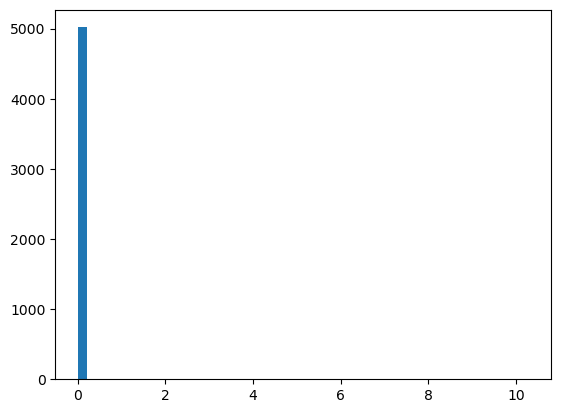

In [14]:
plt.hist(-np.log10(ds.padj),bins=50)

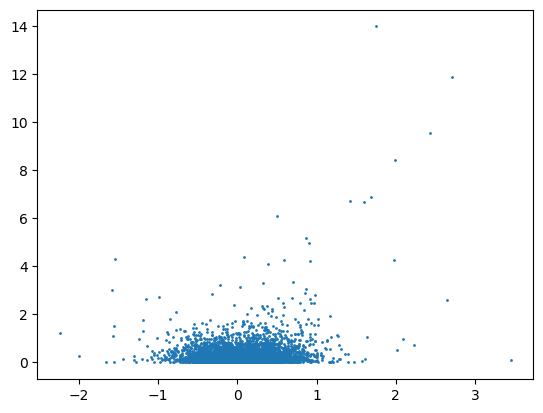

In [15]:
plt.figure()
plt.scatter(
    ds.LFC['exp_condition[T.Mtz]'],
    # -np.log10(ds.padj),
    -np.log10(ds.p_values),
    # ds.statistics,
    s=1,
)
plt.show()

# Subset RGCs

In [16]:
pseudobulk_subset = pseudobulks[pseudobulks.obs['cell_type'] == "RGCs"]
pseudobulk_subset.var_names = data.var_names
inference = DefaultInference(n_cpus=8)
dds_sub = DeseqDataSet(
    counts=pseudobulk_subset.X+1,
    metadata=pseudobulk_subset.obs,
    # design="~ exp_condition + time + exp_condition:time",
    design="~ exp_condition + time",
    refit_cooks=True,
    inference=inference,
)


In [17]:
dds_sub.deseq2()

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.15 seconds.

Fitting dispersion trend curve...
/home/bmb/miniconda3/envs/ceisel_mumm/lib/python3.14/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.04 seconds.

/home/bmb/miniconda3/envs/ceisel_mumm/lib/python3.14/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.21 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



In [18]:
ds_sub = DeseqStats(dds_sub, contrast=["exp_condition", "Mtz", "Cntr"], inference=inference)

In [19]:
ds_sub.summary()

Log2 fold change & Wald test p-value: exp_condition Mtz vs Cntr
      baseMean  log2FoldChange     lfcSE          stat    pvalue  padj
0        1.500    4.462888e-12  0.956739  4.664687e-12  1.000000   1.0
1        1.000    1.362031e-16  1.120947  1.215071e-16  1.000000   1.0
2        1.375   -7.105975e-01  1.033026 -6.878798e-01  0.491528   1.0
3        7.125   -1.162612e+00  0.660580 -1.759985e+00  0.078410   1.0
4        8.875   -2.300459e-01  0.622669 -3.694512e-01  0.711791   1.0
...        ...             ...       ...           ...       ...   ...
5052     1.125    3.048642e-01  1.076009  2.833288e-01  0.776925   1.0
5053     1.000    1.362031e-16  1.120947  1.215071e-16  1.000000   1.0
5054     1.000    1.362031e-16  1.120947  1.215071e-16  1.000000   1.0
5055     1.000    1.362031e-16  1.120947  1.215071e-16  1.000000   1.0
5056     2.500   -5.923398e-01  0.814701 -7.270638e-01  0.467187   1.0

[5057 rows x 6 columns]


Running Wald tests...
... done in 0.10 seconds.



In [20]:
ds_sub.LFC

,Intercept,exp_condition[T.Mtz],time[T.24],time[T.48],time[T.72]
0,9.055565e-07,3.093438e-12,6.931460e-01,4.054640e-01,4.054640e-01
1,4.675986e-11,9.440881e-17,1.888190e-16,1.888190e-16,1.888190e-16
2,2.267143e-01,-4.925486e-01,-3.973464e-07,-3.973464e-07,8.750720e-01
3,2.771625e+00,-8.058611e-01,-3.324251e-01,-9.334064e-01,-1.229291e+00
4,2.764343e+00,-1.594557e-01,-1.066054e+00,-5.213079e-01,-7.595463e-01
...,...,...,...,...,...
5052,2.885321e-01,2.113158e-01,-3.978531e-01,-3.978531e-01,-3.978531e-01
5053,4.675986e-11,9.440881e-17,1.888190e-16,1.888190e-16,1.888190e-16
5054,4.675986e-11,9.440881e-17,1.888190e-16,1.888190e-16,1.888190e-16
5055,4.675986e-11,9.440881e-17,1.888190e-16,1.888190e-16,1.888190e-16


In [21]:
lfc_cutoff = 1
pval_cutoff = 1

padj_cutoff = 0.05

genes_to_mark = (
    (np.abs(ds_sub.LFC['exp_condition[T.Mtz]']) > lfc_cutoff) &
    (-np.log10(ds_sub.p_values) > pval_cutoff)
    # (-np.log10(ds_sub.padj) > padj_cutoff)
)
# np.abs(ds_sub.LFC['exp_condition[T.Mtz]'])


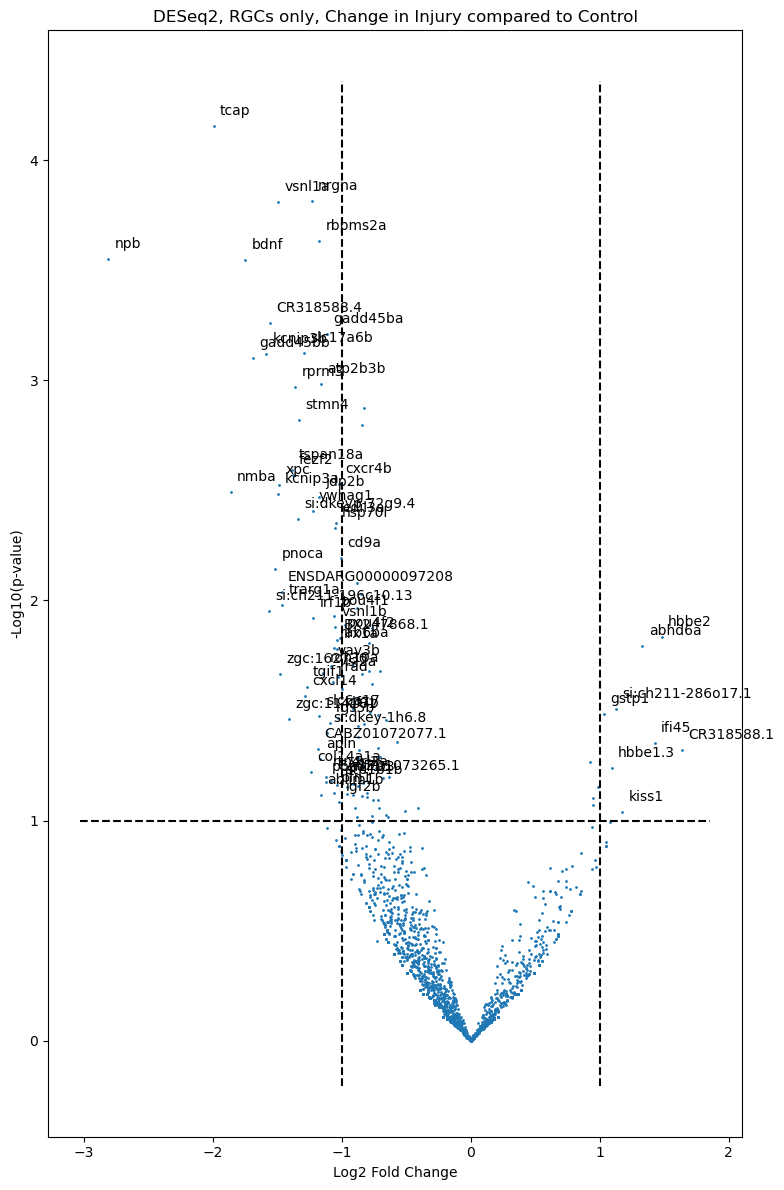

In [26]:
plt.figure(figsize=(8,12))
plt.title("DESeq2, RGCs only, Change in Injury compared to Control")

x = ds_sub.LFC['exp_condition[T.Mtz]']
y = -np.log10(ds_sub.p_values)
# y = -np.log10(ds_sub.padj)
plt.scatter(
    x,y,
    s=1,
)
ax = plt.gca()
offset = 0.05
for gene,x,y in zip(pseudobulk_subset.var_names[genes_to_mark],x[genes_to_mark],y[genes_to_mark]):
    ax.text(
        x + offset,y + offset,
        gene,fontsize=10)

ylims = ax.get_ylim()
xlims = ax.get_xlim()
plt.plot([lfc_cutoff,lfc_cutoff],ylims,'k--')
plt.plot([-lfc_cutoff,-lfc_cutoff],ylims,'k--')
plt.plot(xlims,[pval_cutoff,pval_cutoff],'k--')

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10(p-value)")
plt.tight_layout()
plt.show()

# Signature Sets

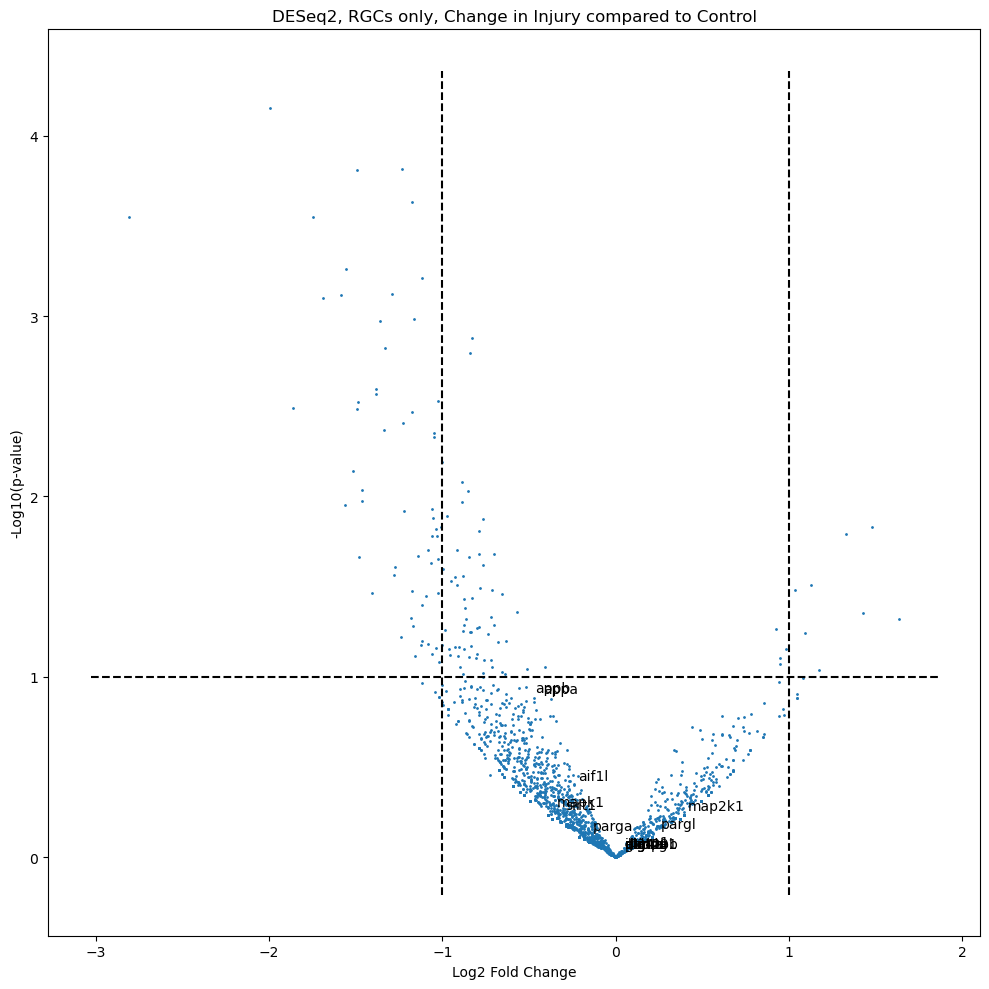

In [30]:
# Selecting signature genes only 



signature = 'parthanatos'
genes_to_mark = data.var[signature]
genes_to_mark = np.array(genes_to_mark)

plt.figure(figsize=(10,10))
plt.title("DESeq2, RGCs only, Change in Injury compared to Control")

x = ds_sub.LFC['exp_condition[T.Mtz]']
y = -np.log10(ds_sub.p_values)
# y = -np.log10(ds_sub.padj)
plt.scatter(
    x,y,
    s=1,
)
ax = plt.gca()
offset = 0.05
for gene,x,y in zip(pseudobulk_subset.var_names[genes_to_mark],x[genes_to_mark],y[genes_to_mark]):
    ax.text(
        x + offset,y + offset,
        gene,fontsize=10)

ylims = ax.get_ylim()
xlims = ax.get_xlim()
plt.plot([lfc_cutoff,lfc_cutoff],ylims,'k--')
plt.plot([-lfc_cutoff,-lfc_cutoff],ylims,'k--')
plt.plot(xlims,[pval_cutoff,pval_cutoff],'k--')

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10(p-value)")
plt.tight_layout()
plt.show()

In [31]:
for signature in ['parthanatos','necroptosis','apoptosis']:
    mask = np.array(data.var[signature])

    print("-"*100)
    print(f"Signature: {signature}")
    print(f"Total: \t{np.sum(ds_sub.LFC['exp_condition[T.Mtz]'][mask])}")
    print(f"\t\t{'\t'.join([f'{g[:6]},' for g in data.var_names[mask]])}")
    print(f"LFCs: \t\t{'\t'.join(np.around(ds_sub.LFC['exp_condition[T.Mtz]'][mask],3).astype(str))}")
    print(f"pvals: \t\t{'\t'.join(np.around(ds_sub.p_values[mask],3).astype(str))}")
    print(f"padjs: \t\t{'\t'.join(np.around(ds_sub.padj[mask],3).astype(str))}")

----------------------------------------------------------------------------------------------------
Signature: parthanatos
Total: 	-1.5626342446635482
		mapk1,	aif1l,	dlg4a,	appa,	grin2b,	appb,	parp1,	plat,	endog,	mmp9,	parga,	sirt1,	map2k1,	dlg4b,	dlg4b-,	il1b,	pargl,
LFCs: 		-0.393	-0.267	0.0	-0.47	0.0	-0.517	0.026	0.0	0.0	0.0	-0.182	-0.34	0.369	0.0	0.0	0.0	0.211
pvals: 		0.587	0.421	1.0	0.137	1.0	0.137	0.969	1.0	1.0	1.0	0.792	0.611	0.612	1.0	1.0	1.0	0.777
padjs: 		1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0
----------------------------------------------------------------------------------------------------
Signature: necroptosis
Total: 	-0.9586790447508734
		ripk3,	tradd,	cylda,	fadd,	pgam5,	igfbp2,	cyldl,	ripk1l,	igfbp2,	tnfrsf,	vdac2,	vdac1,	cyldb,	rbck1,	dnm1l,
LFCs: 		0.0	0.0	-0.392	0.0	0.0	0.0	0.0	0.0	-0.211	0.0	-0.272	-0.269	0.211	0.0	-0.026
pvals: 		1.0	1.0	0.527	1.0	1.0	1.0	1.0	1.0	0.777	1.0	0.327	0.311	0.777	1.0	0.969
padjs: 		1.0	1.0	1.0	1.0	1.0	1.

In [32]:
sc.pl.dotplot(data,parthanatos_signature,groupby="time")

NameError: name 'parthanatos_signature' is not defined